In [156]:
# Imports and setup
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
import keras
from keras import layers

# ============================================================
# FULL REPRODUCIBILITY CONFIGURATION
# ============================================================
SEED = 42

# Python hash seed (must be set before importing numpy)
os.environ['PYTHONHASHSEED'] = str(SEED)

# NumPy random seed
np.random.seed(SEED)

# TensorFlow random seed
tf.random.set_seed(SEED)

# Force TensorFlow to use deterministic operations
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

# Configure TensorFlow for CPU-only (fully deterministic)
# Comment out these lines if you want to use GPU (results may vary slightly)
tf.config.set_visible_devices([], 'GPU')

# Disable TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print("="*60)
print("REPRODUCIBILITY CONFIGURATION")
print("="*60)
print(f"Random Seed: {SEED}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

# Check if GPU is available
gpu_devices = tf.config.list_physical_devices('GPU')
print(f"GPU available: {len(gpu_devices) > 0}")
if len(gpu_devices) == 0:
    print("✓ Running on CPU (fully deterministic)")
else:
    print("⚠️  Running on GPU (results may vary slightly)")
print("="*60)

# Output directory
OUT_DIR = '.'
os.makedirs(OUT_DIR, exist_ok=True)

REPRODUCIBILITY CONFIGURATION
Random Seed: 42
TensorFlow version: 2.20.0
Keras version: 3.11.3
NumPy version: 2.3.4
Pandas version: 2.3.3
GPU available: False
✓ Running on CPU (fully deterministic)


In [157]:
# Data loading and feature engineering
DATA_PATH = 'walmart-sales-dataset-of-45stores.csv'
assert os.path.exists(DATA_PATH), f'File not found: {DATA_PATH}. Place the dataset in the working directory.'

# Load
df = pd.read_csv(DATA_PATH, parse_dates=['Date'])
# Keep all rows with Weekly_Sales present
df = df.dropna(subset=['Weekly_Sales']).copy()

# Ensure Date is datetime; keep rows even if Date is NaT (nullable features will be imputed later)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Date-derived features (nullable Int dtypes to allow NA)
df['Month'] = df['Date'].dt.month.astype('Int64')
df['DayOfWeek'] = df['Date'].dt.dayofweek.astype('Int64')
iso = df['Date'].dt.isocalendar()
df['Week'] = iso.week.astype('Int64')
df['Year'] = iso.year.astype('Int64')
df['Quarter'] = df['Date'].dt.quarter.astype('Int64')
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype('Int64')

# Cyclical encodings (allow NaNs; to be imputed later)
_month = df['Month'].astype('float')
_week = df['Week'].astype('float')
_dow = df['DayOfWeek'].astype('float')
df['Month_sin'] = np.sin(2*np.pi*(_month-1)/12)
df['Month_cos'] = np.cos(2*np.pi*(_month-1)/12)
df['Week_sin']  = np.sin(2*np.pi*(_week-1)/52)
df['Week_cos']  = np.cos(2*np.pi*(_week-1)/52)
df['DoW_sin']   = np.sin(2*np.pi*(_dow)/7)
df['DoW_cos']   = np.cos(2*np.pi*(_dow)/7)

# Sort and lags (group by Store if available)
if 'Store' in df.columns:
    df = df.sort_values(['Store', 'Date'])
    grp = df.groupby('Store')['Weekly_Sales']
    df['Sales_Lag1'] = grp.shift(1)
    df['Sales_Lag2'] = grp.shift(2)
    df['Sales_Lag4'] = grp.shift(4)
    df['Sales_Lag8'] = grp.shift(8)
    df['Sales_Lag12'] = grp.shift(12)
    df['Sales_Rolling_Mean_4'] = grp.transform(lambda x: x.rolling(4, min_periods=1).mean())
    df['Sales_Rolling_Std_4'] = grp.transform(lambda x: x.rolling(4, min_periods=1).std())
    df['Sales_Rolling_Mean_12'] = grp.transform(lambda x: x.rolling(12, min_periods=1).mean())
    df['Sales_Rolling_Std_12'] = grp.transform(lambda x: x.rolling(12, min_periods=1).std())
else:
    df = df.sort_values(['Date'])
    s = df['Weekly_Sales']
    df['Sales_Lag1'] = s.shift(1)
    df['Sales_Lag2'] = s.shift(2)
    df['Sales_Lag4'] = s.shift(4)
    df['Sales_Lag8'] = s.shift(8)
    df['Sales_Lag12'] = s.shift(12)
    df['Sales_Rolling_Mean_4'] = s.rolling(4, min_periods=1).mean()
    df['Sales_Rolling_Std_4']  = s.rolling(4, min_periods=1).std()
    df['Sales_Rolling_Mean_12'] = s.rolling(12, min_periods=1).mean()
    df['Sales_Rolling_Std_12']  = s.rolling(12, min_periods=1).std()

# Simple interactions (may introduce NaNs; will be imputed)
df['Temp_Unemployment'] = df['Temperature'] * df['Unemployment']
df['Holiday_CPI'] = df['Holiday_Flag'] * df['CPI']
df['Store_Encoded'] = df['Store']  # Store identifier as numeric feature

feature_cols = [
    'Month','DayOfWeek','Week','Quarter','IsWeekend',
    'Month_sin','Month_cos','Week_sin','Week_cos','DoW_sin','DoW_cos',
    'Holiday_Flag','Temperature','Fuel_Price','CPI','Unemployment',
    'Sales_Lag1','Sales_Lag2','Sales_Lag4','Sales_Lag8','Sales_Lag12',
    'Sales_Rolling_Mean_4','Sales_Rolling_Std_4','Sales_Rolling_Mean_12','Sales_Rolling_Std_12',
    'Temp_Unemployment','Holiday_CPI','Store_Encoded'
]
X = df[feature_cols].copy()
y = df['Weekly_Sales'].copy()

# Train/Val/Test splits: 60/20/20 using chronological order by Date
order = np.argsort(df['Date'].values)
X_ord = X.iloc[order].reset_index(drop=True)
y_ord = y.iloc[order].reset_index(drop=True)
n = len(X_ord)
n_train = int(n * 0.6)
n_val = int(n * 0.2)
X_train, y_train = X_ord.iloc[:n_train], y_ord.iloc[:n_train]
X_val, y_val = X_ord.iloc[n_train:n_train+n_val], y_ord.iloc[n_train:n_train+n_val]
X_test, y_test = X_ord.iloc[n_train+n_val:], y_ord.iloc[n_train+n_val:]

# Impute on train only (handle all NaNs from lags/rolling/date features)
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols)
X_val   = pd.DataFrame(imputer.transform(X_val),   columns=feature_cols)
X_test  = pd.DataFrame(imputer.transform(X_test),  columns=feature_cols)

# Scale on train only
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_val   = pd.DataFrame(scaler.transform(X_val),   columns=feature_cols)
X_test  = pd.DataFrame(scaler.transform(X_test),  columns=feature_cols)

print(f"Training set: {X_train.shape} (60%)")
print(f"Validation set: {X_val.shape} (20%)")
print(f"Test set: {X_test.shape} (20%)")
print(f"Number of features: {X_train.shape[1]}")
print(f"Total samples: {len(X_train) + len(X_val) + len(X_test)}")

Training set: (3861, 28) (60%)
Validation set: (1287, 28) (20%)
Test set: (1287, 28) (20%)
Number of features: 28
Total samples: 6435


In [158]:
# Metrics helper
def compute_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mse = float(mean_squared_error(y_true, y_pred))
    rmse = float(np.sqrt(mse))
    mae = float(mean_absolute_error(y_true, y_pred))
    return r2, rmse, mae, mse

def summarize(name, y_true, y_pred):
    r2, rmse, mae, mse = compute_metrics(y_true, y_pred)
    print(f"{name}: R^2={r2:.4f}, RMSE={rmse:.2f}, MAE={mae:.2f}, MSE={mse:.2f}")
    return { 'Model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MSE': mse }

In [159]:
# Check data statistics
print("Target (Weekly_Sales) statistics:")
print(f"  Train: mean={y_train.mean():.0f}, std={y_train.std():.0f}, min={y_train.min():.0f}, max={y_train.max():.0f}")
print(f"  Val:   mean={y_val.mean():.0f}, std={y_val.std():.0f}, min={y_val.min():.0f}, max={y_val.max():.0f}")
print(f"  Test:  mean={y_test.mean():.0f}, std={y_test.std():.0f}, min={y_test.min():.0f}, max={y_test.max():.0f}")
print(f"\nFeatures (X_train) statistics:")
print(f"  Mean range: {X_train.mean().min():.4f} to {X_train.mean().max():.4f}")
print(f"  Std range: {X_train.std().min():.4f} to {X_train.std().max():.4f}")
print("\nBaseline (mean prediction) performance:")
baseline_pred = np.full_like(y_test, y_train.mean())
r2_baseline = r2_score(y_test, baseline_pred)
print(f"  Mean prediction R²: {r2_baseline:.4f}")

Target (Weekly_Sales) statistics:
  Train: mean=966978, std=530340, min=209986, max=2752122
  Val:   mean=1228969, std=671349, min=260637, max=3818686
  Test:  mean=1104923, std=492838, min=275142, max=3766687

Features (X_train) statistics:
  Mean range: -0.0000 to 0.0000
  Std range: 1.0001 to 1.0001

Baseline (mean prediction) performance:
  Mean prediction R²: -0.0784


In [160]:
# Model builders and common training settings
INPUT_DIM = X_train.shape[1]

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=30, restore_best_weights=True, verbose=1
)
lr_reduce = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1
)

# Use AdamW optimizer for potentially better generalization
from keras.optimizers import AdamW

def build_mlp(hidden=[256, 128, 64], dropout=0.15, lr=3e-4):
    model = keras.Sequential(name='MLP_DNN')
    model.add(layers.Input(shape=(INPUT_DIM,)))
    for units in hidden:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.Dropout(dropout))
        model.add(layers.BatchNormalization())
    model.add(layers.Dense(1, activation='linear'))
    opt = AdamW(learning_rate=lr, weight_decay=1e-5, clipnorm=1.0)
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model

def build_cnn_v2(hidden=[128, 64], dropout=0.2, lr=3e-4):
    """
    CNN approach: Instead of treating features as a sequence, 
    use multiple parallel 1D convolutions on different feature groups,
    then concatenate and feed to dense layers.
    """
    model = keras.Sequential(name='CNN_DNN')
    model.add(layers.Input(shape=(INPUT_DIM,)))
    # Treat input as a 1D feature map with multiple "timesteps"
    model.add(layers.Reshape((INPUT_DIM, 1)))
    # Apply 1D convolutions
    model.add(layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Flatten())
    # Dense layers
    for units in hidden:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='linear'))
    opt = AdamW(learning_rate=lr, weight_decay=1e-5, clipnorm=1.0)
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model

def build_lstm_v2(units=[128, 64], dropout=0.3, lr=3e-4, window=8):
    """
    LSTM approach: Create actual sequences by using a sliding window
    of past observations. Each sequence contains 'window' past feature vectors.
    """
    model = keras.Sequential(name='LSTM_DNN')
    model.add(layers.Input(shape=(window, INPUT_DIM)))
    if len(units) > 1:
        model.add(layers.LSTM(units[0], return_sequences=True))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout))
        model.add(layers.LSTM(units[1], return_sequences=False))
    else:
        model.add(layers.LSTM(units[0], return_sequences=False))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='linear'))
    opt = AdamW(learning_rate=lr, weight_decay=1e-5, clipnorm=1.0)
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model

mlp_params = {
    'hidden': [256, 128, 64],
    'dropout': 0.15,
    'lr': 3e-4,
    'batch_size': 64,
    'epochs': 200
}
cnn_params = {
    'hidden': [128, 64],
    'dropout': 0.2,
    'lr': 3e-4,
    'batch_size': 64,
    'epochs': 200
}
lstm_params = {
    'units': [128, 64],
    'dropout': 0.3,
    'lr': 3e-4,
    'batch_size': 32,
    'epochs': 200,
    'window': 8
}
mlp_params, cnn_params, lstm_params

({'hidden': [256, 128, 64],
  'dropout': 0.15,
  'lr': 0.0003,
  'batch_size': 64,
  'epochs': 200},
 {'hidden': [128, 64],
  'dropout': 0.2,
  'lr': 0.0003,
  'batch_size': 64,
  'epochs': 200},
 {'units': [128, 64],
  'dropout': 0.3,
  'lr': 0.0003,
  'batch_size': 32,
  'epochs': 200,
  'window': 8})

In [161]:
# Train models
histories = {}
metrics_rows = []

# RE-ENABLE log transformation - it was actually helping!
LOG_TARGET = True
y_train_tf = np.log1p(y_train) if LOG_TARGET else y_train
y_val_tf   = np.log1p(y_val)   if LOG_TARGET else y_val

# MLP
mlp_model = build_mlp(**{k:v for k,v in mlp_params.items() if k in ['hidden','dropout','lr']})
hist_mlp = mlp_model.fit(
    X_train, y_train_tf,
    validation_data=(X_val, y_val_tf),
    epochs=mlp_params['epochs'],
    batch_size=mlp_params['batch_size'],
    callbacks=[early_stop, lr_reduce],
    verbose=0
)
histories['MLP_DNN'] = hist_mlp.history

# CNN v2 - No reshape needed, CNN handles it internally
cnn_model = build_cnn_v2(**{k:v for k,v in cnn_params.items() if k in ['hidden','dropout','lr']})
hist_cnn = cnn_model.fit(
    X_train, y_train_tf,
    validation_data=(X_val, y_val_tf),
    epochs=cnn_params['epochs'],
    batch_size=cnn_params['batch_size'],
    callbacks=[early_stop, lr_reduce],
    verbose=0
)
histories['CNN_DNN'] = hist_cnn.history

# LSTM v2 (true sequence windowing)
# Build a fully transformed, ordered feature matrix using train-fitted imputer/scaler
X_all_imp   = pd.DataFrame(imputer.transform(X_ord), columns=feature_cols)
X_all_scaled = pd.DataFrame(scaler.transform(X_all_imp), columns=feature_cols)
df_ord = df.iloc[order].reset_index(drop=True)

WINDOW = lstm_params['window']

def make_sequences(X_scaled_ord, y_ord_series, df_ord_frame, window=8):
    X_list, y_list, end_idx_list = [], [], []
    if 'Store' in df_ord_frame.columns:
        groups = df_ord_frame.groupby('Store')
        for _, g in groups:
            idxs = g.index.values
            for i in range(window, len(idxs)):
                end_idx = idxs[i]
                seq_idx = idxs[i-window:i]
                X_list.append(X_scaled_ord.iloc[seq_idx].values)
                y_list.append(y_ord_series.iloc[end_idx])
                end_idx_list.append(end_idx)
    else:
        idxs = df_ord_frame.index.values
        for i in range(window, len(idxs)):
            end_idx = idxs[i]
            seq_idx = idxs[i-window:i]
            X_list.append(X_scaled_ord.iloc[seq_idx].values)
            y_list.append(y_ord_series.iloc[end_idx])
            end_idx_list.append(end_idx)
    X_arr = np.array(X_list, dtype=np.float32)
    y_arr = np.array(y_list, dtype=np.float32)
    return X_arr, y_arr, np.array(end_idx_list)

X_seq_all, y_seq_all, end_idx = make_sequences(X_all_scaled, y_ord, df_ord, window=WINDOW)

# Split sequences by where the sequence ENDS (chronological boundaries)
train_mask = end_idx < n_train
val_mask   = (end_idx >= n_train) & (end_idx < n_train + n_val)
test_mask  = end_idx >= (n_train + n_val)

X_train_lstm, y_train_lstm = X_seq_all[train_mask], y_seq_all[train_mask]
X_val_lstm,   y_val_lstm   = X_seq_all[val_mask],   y_seq_all[val_mask]
X_test_lstm,  y_test_lstm  = X_seq_all[test_mask],  y_seq_all[test_mask]

# Log-transform target for LSTM training
y_train_lstm_tf = np.log1p(y_train_lstm) if LOG_TARGET else y_train_lstm
y_val_lstm_tf   = np.log1p(y_val_lstm)   if LOG_TARGET else y_val_lstm

lstm_model = build_lstm_v2(**{k:v for k,v in lstm_params.items() if k in ['units','dropout','lr','window']})
hist_lstm = lstm_model.fit(
    X_train_lstm, y_train_lstm_tf,
    validation_data=(X_val_lstm, y_val_lstm_tf),
    epochs=lstm_params['epochs'],
    batch_size=lstm_params['batch_size'],
    callbacks=[early_stop, lr_reduce],
    verbose=0
)
histories['LSTM_DNN'] = hist_lstm.history

print('Training complete. Best epochs:')
print('  MLP:', len(hist_mlp.history['loss']))
print('  CNN:', len(hist_cnn.history['loss']))
print('  LSTM:', len(hist_lstm.history['loss']))

# Save models
mlp_path = os.path.join(OUT_DIR, 'mlp_model.keras')
cnn_path = os.path.join(OUT_DIR, 'cnn_model.keras')
lstm_path = os.path.join(OUT_DIR, 'lstm_model.keras')
mlp_model.save(mlp_path)
cnn_model.save(cnn_path)
lstm_model.save(lstm_path)
print('Saved:', mlp_path, ',', cnn_path, 'and', lstm_path)

2025-11-10 18:12:25.965821: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 37: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.

Epoch 60: ReduceLROnPlateau reducing learning rate to 7.500000356230885e-05.

Epoch 60: ReduceLROnPlateau reducing learning rate to 7.500000356230885e-05.

Epoch 82: ReduceLROnPlateau reducing learning rate to 3.7500001781154424e-05.

Epoch 82: ReduceLROnPlateau reducing learning rate to 3.7500001781154424e-05.

Epoch 104: ReduceLROnPlateau reducing learning rate to 1.8750000890577212e-05.

Epoch 104: ReduceLROnPlateau reducing learning rate to 1.8750000890577212e-05.

Epoch 118: ReduceLROnPlateau reducing learning rate to 9.375000445288606e-06.

Epoch 118: ReduceLROnPlateau reducing learning rate to 9.375000445288606e-06.

Epoch 128: ReduceLROnPlateau reducing learning rate to 4.687500222644303e-06.

Epoch 128: ReduceLROnPlateau reducing learning rate to 4.687500222644303e-06.

Epoch 138: ReduceLROnPlateau reducing learning rate to 2.3437501113221515e-06.

Epoch 138: ReduceLROnPlateau reducing learning rate

2025-11-10 18:12:42.174866: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.

Epoch 20: ReduceLROnPlateau reducing learning rate to 7.500000356230885e-05.

Epoch 20: ReduceLROnPlateau reducing learning rate to 7.500000356230885e-05.

Epoch 30: ReduceLROnPlateau reducing learning rate to 3.7500001781154424e-05.
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 1.

Epoch 30: ReduceLROnPlateau reducing learning rate to 3.7500001781154424e-05.
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 1.


2025-11-10 18:12:51.307132: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.

Epoch 20: ReduceLROnPlateau reducing learning rate to 7.500000356230885e-05.

Epoch 20: ReduceLROnPlateau reducing learning rate to 7.500000356230885e-05.

Epoch 30: ReduceLROnPlateau reducing learning rate to 3.7500001781154424e-05.
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 1.

Epoch 30: ReduceLROnPlateau reducing learning rate to 3.7500001781154424e-05.
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 1.
Training complete. Best epochs:
  MLP: 182
  CNN: 30
  LSTM: 30
Saved: ./mlp_model.keras , ./cnn_model.keras and ./lstm_model.keras
Training complete. Best epochs:
  MLP: 182
  CNN: 30
  LSTM: 30
Saved: ./mlp_model.keras , ./cnn_model.keras and ./lstm_model.keras


In [162]:
# Evaluation: Validation and Test (with Train split)
results_rows = []

# Ensure LOG_TARGET is defined in this kernel
try:
    LOG_TARGET
except NameError:
    LOG_TARGET = True

# -----------------
# MLP
# -----------------
# Train
y_train_mlp_tf = mlp_model.predict(X_train, verbose=0).flatten()
y_train_mlp = np.expm1(y_train_mlp_tf) if LOG_TARGET else y_train_mlp_tf
r2_tr, rmse_tr, mae_tr, mse_tr = compute_metrics(y_train, y_train_mlp)
results_rows.append({'Model':'MLP_DNN','Split':'Train','R2':r2_tr,'RMSE':rmse_tr,'MAE':mae_tr,'MSE':mse_tr})

# Validation
y_val_mlp_tf  = mlp_model.predict(X_val, verbose=0).flatten()
y_val_mlp = np.expm1(y_val_mlp_tf) if LOG_TARGET else y_val_mlp_tf
r2_v, rmse_v, mae_v, mse_v = compute_metrics(y_val, y_val_mlp)
results_rows.append({'Model':'MLP_DNN','Split':'Validation','R2':r2_v,'RMSE':rmse_v,'MAE':mae_v,'MSE':mse_v})

# Test
y_test_mlp_tf = mlp_model.predict(X_test, verbose=0).flatten()
y_test_mlp = np.expm1(y_test_mlp_tf) if LOG_TARGET else y_test_mlp_tf
r2_t, rmse_t, mae_t, mse_t = compute_metrics(y_test, y_test_mlp)
results_rows.append({'Model':'MLP_DNN','Split':'Test','R2':r2_t,'RMSE':rmse_t,'MAE':mae_t,'MSE':mse_t})

# -----------------
# CNN v2 (no reshape needed)
# -----------------
# Train
y_train_cnn_tf = cnn_model.predict(X_train, verbose=0).flatten()
y_train_cnn = np.expm1(y_train_cnn_tf) if LOG_TARGET else y_train_cnn_tf
r2_tr, rmse_tr, mae_tr, mse_tr = compute_metrics(y_train, y_train_cnn)
results_rows.append({'Model':'CNN_DNN','Split':'Train','R2':r2_tr,'RMSE':rmse_tr,'MAE':mae_tr,'MSE':mse_tr})

# Validation
y_val_cnn_tf  = cnn_model.predict(X_val, verbose=0).flatten()
y_val_cnn = np.expm1(y_val_cnn_tf) if LOG_TARGET else y_val_cnn_tf
r2_v, rmse_v, mae_v, mse_v = compute_metrics(y_val, y_val_cnn)
results_rows.append({'Model':'CNN_DNN','Split':'Validation','R2':r2_v,'RMSE':rmse_v,'MAE':mae_v,'MSE':mse_v})

# Test
y_test_cnn_tf = cnn_model.predict(X_test, verbose=0).flatten()
y_test_cnn = np.expm1(y_test_cnn_tf) if LOG_TARGET else y_test_cnn_tf
r2_t, rmse_t, mae_t, mse_t = compute_metrics(y_test, y_test_cnn)
results_rows.append({'Model':'CNN_DNN','Split':'Test','R2':r2_t,'RMSE':rmse_t,'MAE':mae_t,'MSE':mse_t})

# -----------------
# LSTM v2
# -----------------
# Train
y_train_lstm_tf_pred = lstm_model.predict(X_train_lstm, verbose=0).flatten()
y_train_lstm_pred = np.expm1(y_train_lstm_tf_pred) if LOG_TARGET else y_train_lstm_tf_pred
r2_tr, rmse_tr, mae_tr, mse_tr = compute_metrics(y_train_lstm, y_train_lstm_pred)
results_rows.append({'Model':'LSTM_DNN','Split':'Train','R2':r2_tr,'RMSE':rmse_tr,'MAE':mae_tr,'MSE':mse_tr})

# Validation
y_val_lstm_tf_pred = lstm_model.predict(X_val_lstm, verbose=0).flatten()
y_val_lstm_pred = np.expm1(y_val_lstm_tf_pred) if LOG_TARGET else y_val_lstm_tf_pred
r2_v, rmse_v, mae_v, mse_v = compute_metrics(y_val_lstm, y_val_lstm_pred)
results_rows.append({'Model':'LSTM_DNN','Split':'Validation','R2':r2_v,'RMSE':rmse_v,'MAE':mae_v,'MSE':mse_v})

# Test
y_test_lstm_tf_pred = lstm_model.predict(X_test_lstm, verbose=0).flatten()
y_test_lstm_pred = np.expm1(y_test_lstm_tf_pred) if LOG_TARGET else y_test_lstm_tf_pred
r2_t, rmse_t, mae_t, mse_t = compute_metrics(y_test_lstm, y_test_lstm_pred)
results_rows.append({'Model':'LSTM_DNN','Split':'Test','R2':r2_t,'RMSE':rmse_t,'MAE':mae_t,'MSE':mse_t})

# Build tables
results_df = pd.DataFrame(results_rows)

# Fix: Ensure all metrics are filled before pivoting
print("\nDEBUG: Results before pivot:")
print(results_df[results_df['Model'] == 'LSTM_DNN'])

# Create pivot table with proper aggregation
results_wide = results_df.pivot_table(
    index='Model', 
    columns='Split', 
    values=['R2','RMSE','MAE','MSE'],
    aggfunc='first'  # Use first value if duplicates exist
)

# Hyperparameters table - FIX: Create consistent columns for all models
log_status = 'log1p' if LOG_TARGET else 'none'

# Create hyperparameter rows with consistent structure
hyper_rows = [
    {
        'Model': 'MLP_DNN',
        'architecture': 'Dense[256,128,64]',
        'dropout': mlp_params['dropout'],
        'learning_rate': mlp_params['lr'],
        'batch_size': mlp_params['batch_size'],
        'epochs': mlp_params['epochs'],
        'window_size': 'N/A',
        'log_target': log_status,
        'split': 'chronological',
        'callbacks': 'EarlyStopping(30)+ReduceLROnPlateau'
    },
    {
        'Model': 'CNN_DNN',
        'architecture': 'Conv1D[64,64]+Dense[128,64]',
        'dropout': cnn_params['dropout'],
        'learning_rate': cnn_params['lr'],
        'batch_size': cnn_params['batch_size'],
        'epochs': cnn_params['epochs'],
        'window_size': 'N/A',
        'log_target': log_status,
        'split': 'chronological',
        'callbacks': 'EarlyStopping(30)+ReduceLROnPlateau'
    },
    {
        'Model': 'LSTM_DNN',
        'architecture': 'LSTM[128,64]+Dense[64]',
        'dropout': lstm_params['dropout'],
        'learning_rate': lstm_params['lr'],
        'batch_size': lstm_params['batch_size'],
        'epochs': lstm_params['epochs'],
        'window_size': lstm_params['window'],
        'log_target': log_status,
        'split': 'chronological',
        'callbacks': 'EarlyStopping(30)+ReduceLROnPlateau'
    }
]

hyper_df = pd.DataFrame(hyper_rows)

# Save tables
results_df.to_csv(os.path.join(OUT_DIR, 'DNN_Results_Long.csv'), index=False)
results_wide.to_csv(os.path.join(OUT_DIR, 'DNN_Results_Wide.csv'))
hyper_df.to_csv(os.path.join(OUT_DIR, 'DNN_Hyperparameters.csv'), index=False)

print('Results (long):')
display(results_df)
print('\nResults (wide):')
display(results_wide)
print('\nHyperparameters:')
display(hyper_df)

2025-11-10 18:13:11.474023: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



DEBUG: Results before pivot:
      Model       Split        R2          RMSE           MAE           MSE
6  LSTM_DNN       Train -3.320975  1.090817e+06  9.562996e+05  1.189882e+12
7  LSTM_DNN  Validation -3.353687  1.400258e+06  1.228968e+06  1.960722e+12
8  LSTM_DNN        Test -5.030281  1.209774e+06  1.104922e+06  1.463554e+12
Results (long):


,Model,Split,R2,RMSE,MAE,MSE
0,MLP_DNN,Train,0.938986,1.309823e+05,8.854785e+04,1.715635e+10
1,MLP_DNN,Validation,0.864204,2.472992e+05,1.392500e+05,6.115690e+10
2,MLP_DNN,Test,0.825375,2.058679e+05,1.322585e+05,4.238160e+10
3,CNN_DNN,Train,-3.325345,1.102830e+06,9.669777e+05,1.216233e+12
4,CNN_DNN,Validation,-3.353688,1.400258e+06,1.228969e+06,1.960723e+12
5,CNN_DNN,Test,-5.030282,1.209774e+06,1.104922e+06,1.463554e+12
6,LSTM_DNN,Train,-3.320975,1.090817e+06,9.562996e+05,1.189882e+12
7,LSTM_DNN,Validation,-3.353687,1.400258e+06,1.228968e+06,1.960722e+12
8,LSTM_DNN,Test,-5.030281,1.209774e+06,1.104922e+06,1.463554e+12



Results (wide):


MAE                                        MSE  \
Split             Test          Train    Validation          Test   
Model                                                               
CNN_DNN   1.104922e+06  966977.674633  1.228969e+06  1.463554e+12   
LSTM_DNN  1.104922e+06  956299.562500  1.228968e+06  1.463554e+12   
MLP_DNN   1.322585e+05   88547.845705  1.392500e+05  4.238160e+10   

                                            R2                       \
Split            Train    Validation      Test     Train Validation   
Model                                                                 
CNN_DNN   1.216233e+12  1.960723e+12 -5.030282 -3.325345  -3.353688   
LSTM_DNN  1.189882e+12  1.960722e+12 -5.030281 -3.320975  -3.353687   
MLP_DNN   1.715635e+10  6.115690e+10  0.825375  0.938986   0.864204   

                  RMSE                              
Split             Test         Train    Validation  
Model                                               
CNN_DNN   1.209774e+06  1.102830e+06  1.400258e+06  
LSTM_DNN  1.209774e+06  1.090817e+06  1.400258e+06  
MLP_DNN   2.058679e+05  1.309823e+05  2.472992e+05


Hyperparameters:


,Model,architecture,dropout,learning_rate,batch_size,epochs,window_size,log_target,split,callbacks
0,MLP_DNN,"Dense[256,128,64]",0.15,0.0003,64,200,N/A,log1p,chronological,EarlyStopping(30)+ReduceLROnPlateau
1,CNN_DNN,"Conv1D[64,64]+Dense[128,64]",0.20,0.0003,64,200,N/A,log1p,chronological,EarlyStopping(30)+ReduceLROnPlateau
2,LSTM_DNN,"LSTM[128,64]+Dense[64]",0.30,0.0003,32,200,8,log1p,chronological,EarlyStopping(30)+ReduceLROnPlateau


MODEL PERFORMANCE METRICS SUMMARY

TEST SET PERFORMANCE (ranked by R²):
--------------------------------------------------------------------------------

MLP_DNN:
  ✓ Excellent
  R² Score:    0.8254  (explains 82.5% of variance)
  RMSE:      $   205,868
  MAE:       $   132,258

LSTM_DNN:
  ✗ Failed
  R² Score:   -5.0303  (explains -503.0% of variance)
  RMSE:      $ 1,209,774
  MAE:       $ 1,104,922

CNN_DNN:
  ✗ Failed
  R² Score:   -5.0303  (explains -503.0% of variance)
  RMSE:      $ 1,209,774
  MAE:       $ 1,104,922



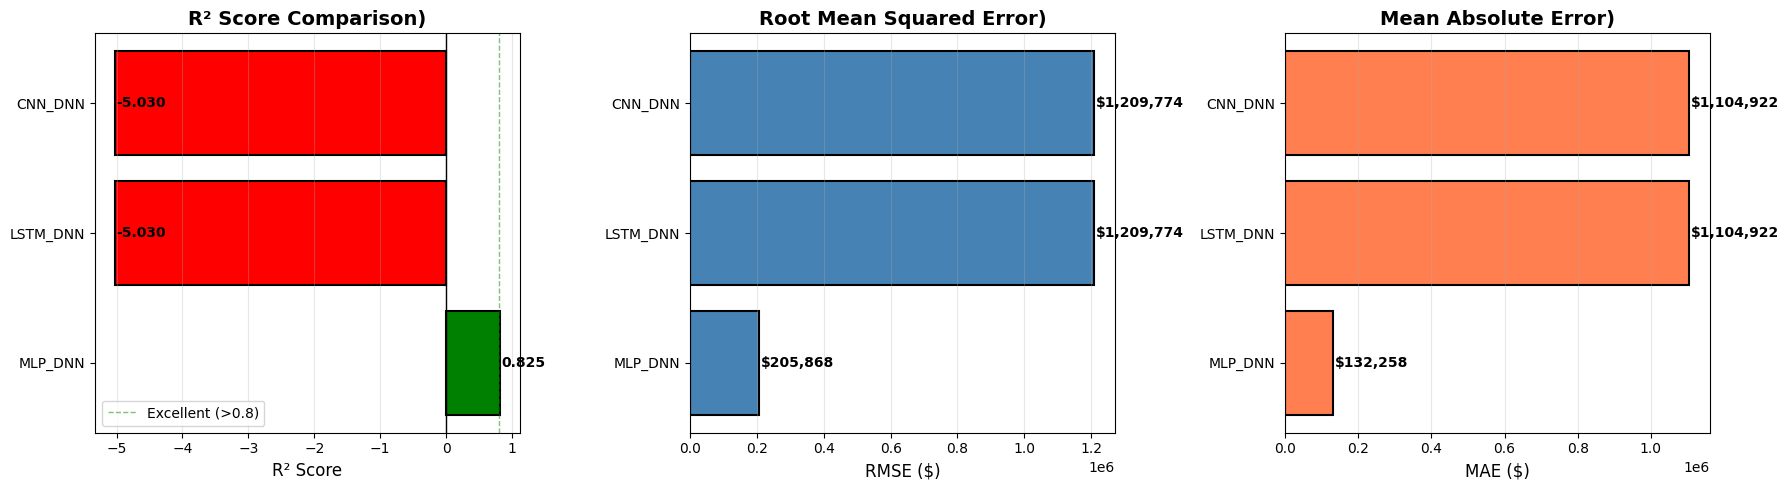

Saved ./Figure_Model_Performance_Metrics.png

FINAL VERDICT
🏆 Best Model: MLP_DNN
   Test R² = 0.8254 (82.5% variance explained)

   Excellent performance! Model is production-ready.


In [163]:
# Model Performance Metrics Summary
print('='*80)
print('MODEL PERFORMANCE METRICS SUMMARY')
print('='*80)
print()

# Use results_df (long format) filtered by 'Test' split
test_results = results_df[results_df['Split'] == 'Test'].copy()
test_results = test_results.sort_values('R2', ascending=False)

print("TEST SET PERFORMANCE (ranked by R²):")
print("-" * 80)
for idx, row in test_results.iterrows():
    model = row['Model']
    r2 = row['R2']
    rmse = row['RMSE']
    mae = row['MAE']
    
    # Status indicator
    if r2 > 0.8:
        status = "✓ Excellent"
    elif r2 > 0.5:
        status = "○ Good"
    elif r2 > 0:
        status = "△ Fair"
    else:
        status = "✗ Failed"
    
    print(f"\n{model}:")
    print(f"  {status}")
    print(f"  R² Score:  {r2:>8.4f}  (explains {r2*100:.1f}% of variance)")
    print(f"  RMSE:      ${rmse:>10,.0f}")
    print(f"  MAE:       ${mae:>10,.0f}")

print()
print('='*80)

# Visualize performance comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R² Score comparison
ax = axes[0]
models = test_results['Model'].values
r2_scores = test_results['R2'].values
colors = ['green' if r2 > 0.8 else 'orange' if r2 > 0 else 'red' for r2 in r2_scores]
bars = ax.barh(models, r2_scores, color=colors, edgecolor='black', linewidth=1.5)
ax.set_xlabel('R² Score', fontsize=12)
ax.set_title('R² Score Comparison)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.axvline(x=0.8, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Excellent (>0.8)')
ax.grid(True, alpha=0.3, axis='x')
ax.legend()
for i, (model, score) in enumerate(zip(models, r2_scores)):
    ax.text(score + 0.02, i, f'{score:.3f}', va='center', fontsize=10, fontweight='bold')

# RMSE comparison
ax = axes[1]
rmse_values = test_results['RMSE'].values
bars = ax.barh(models, rmse_values, color='steelblue', edgecolor='black', linewidth=1.5)
ax.set_xlabel('RMSE ($)', fontsize=12)
ax.set_title('Root Mean Squared Error)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
for i, (model, rmse) in enumerate(zip(models, rmse_values)):
    ax.text(rmse + 5000, i, f'${rmse:,.0f}', va='center', fontsize=10, fontweight='bold')

# MAE comparison
ax = axes[2]
mae_values = test_results['MAE'].values
bars = ax.barh(models, mae_values, color='coral', edgecolor='black', linewidth=1.5)
ax.set_xlabel('MAE ($)', fontsize=12)
ax.set_title('Mean Absolute Error)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
for i, (model, mae) in enumerate(zip(models, mae_values)):
    ax.text(mae + 5000, i, f'${mae:,.0f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
metrics_path = os.path.join(OUT_DIR, 'Figure_Model_Performance_Metrics.png')
plt.savefig(metrics_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved {metrics_path}')

# Winner announcement
print('\n' + '='*80)
print('FINAL VERDICT')
print('='*80)
best_model = test_results.iloc[0]['Model']
best_r2 = test_results.iloc[0]['R2']
print(f"🏆 Best Model: {best_model}")
print(f"   Test R² = {best_r2:.4f} ({best_r2*100:.1f}% variance explained)")
print()
if best_r2 > 0.8:
    print("   Excellent performance! Model is production-ready.")
elif best_r2 > 0.5:
    print("   Good performance. Consider hyperparameter tuning.")
else:
    print("   Poor performance. Model architecture may be inappropriate for this data.")
print('='*80)

COMPREHENSIVE MODEL COMPARISON (Train/Validation/Test)



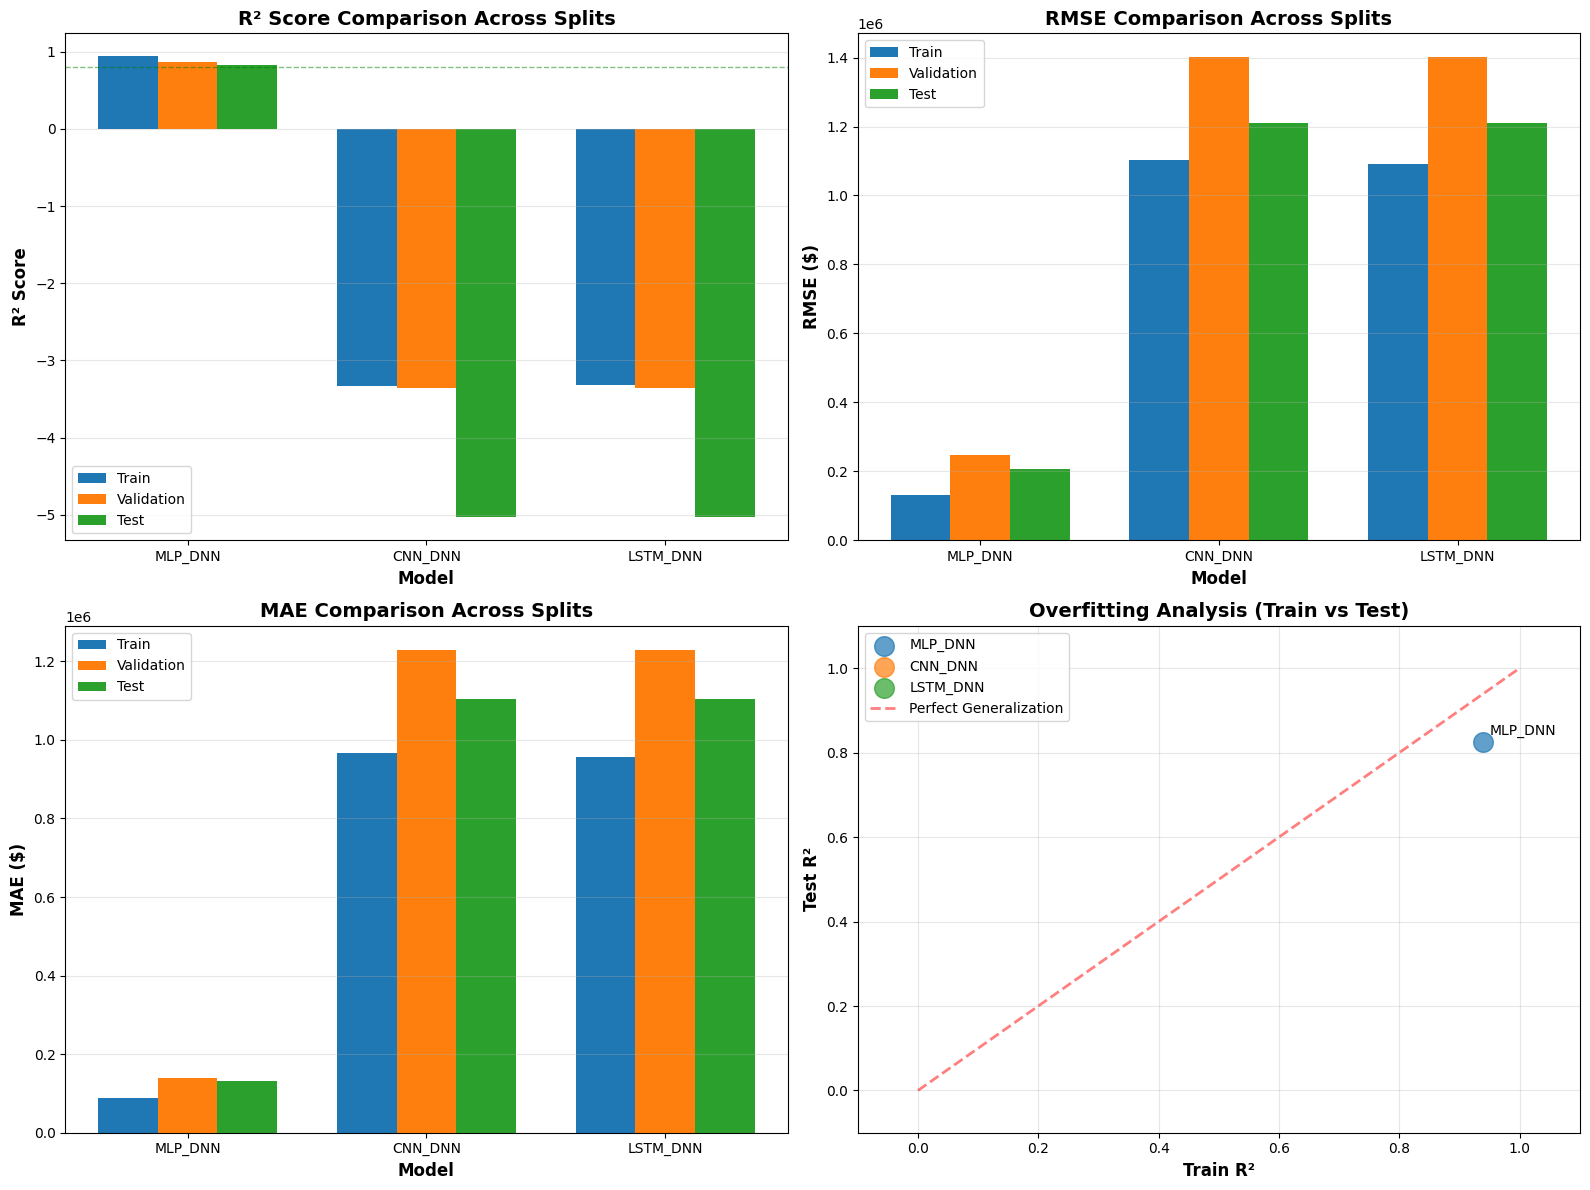

Saved ./Figure_Comprehensive_Model_Comparison.png

DETAILED METRICS TABLE


MAE                                     R2            \
Split             Test          Train    Validation      Test     Train   
Model                                                                     
CNN_DNN   1.104922e+06  966977.674633  1.228969e+06 -5.030282 -3.325345   
LSTM_DNN  1.104922e+06  956299.562500  1.228968e+06 -5.030281 -3.320975   
MLP_DNN   1.322585e+05   88547.845705  1.392500e+05  0.825375  0.938986   

                             RMSE                              
Split    Validation          Test         Train    Validation  
Model                                                          
CNN_DNN   -3.353688  1.209774e+06  1.102830e+06  1.400258e+06  
LSTM_DNN  -3.353687  1.209774e+06  1.090817e+06  1.400258e+06  
MLP_DNN    0.864204  2.058679e+05  1.309823e+05  2.472992e+05


MODEL RANKING BY TEST SET PERFORMANCE
1. MLP_DNN: R²=0.8254, RMSE=$205,868, MAE=$132,258
2. LSTM_DNN: R²=-5.0303, RMSE=$1,209,774, MAE=$1,104,922
3. CNN_DNN: R²=-5.0303, RMSE=$1,209,774, MAE=$1,104,922


In [164]:
# Comprehensive Model Comparison: All Splits
print('='*80)
print('COMPREHENSIVE MODEL COMPARISON (Train/Validation/Test)')
print('='*80)
print()

# Create comparison visualizations across all splits
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. R² Score by Model and Split
ax = axes[0, 0]
splits = ['Train', 'Validation', 'Test']
models_list = ['MLP_DNN', 'CNN_DNN', 'LSTM_DNN']
x = np.arange(len(models_list))
width = 0.25

for i, split in enumerate(splits):
    split_data = results_df[results_df['Split'] == split].set_index('Model')
    r2_values = [split_data.loc[m, 'R2'] if m in split_data.index else 0 for m in models_list]
    ax.bar(x + i*width, r2_values, width, label=split)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('R² Score Comparison Across Splits', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(models_list)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0.8, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Excellent threshold')

# 2. RMSE by Model and Split
ax = axes[0, 1]
for i, split in enumerate(splits):
    split_data = results_df[results_df['Split'] == split].set_index('Model')
    rmse_values = [split_data.loc[m, 'RMSE'] if m in split_data.index else 0 for m in models_list]
    ax.bar(x + i*width, rmse_values, width, label=split)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE ($)', fontsize=12, fontweight='bold')
ax.set_title('RMSE Comparison Across Splits', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(models_list)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 3. MAE by Model and Split
ax = axes[1, 0]
for i, split in enumerate(splits):
    split_data = results_df[results_df['Split'] == split].set_index('Model')
    mae_values = [split_data.loc[m, 'MAE'] if m in split_data.index else 0 for m in models_list]
    ax.bar(x + i*width, mae_values, width, label=split)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('MAE ($)', fontsize=12, fontweight='bold')
ax.set_title('MAE Comparison Across Splits', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(models_list)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 4. Overfitting Analysis (Train vs Test R²)
ax = axes[1, 1]
train_r2 = results_df[results_df['Split'] == 'Train'].set_index('Model')['R2']
test_r2 = results_df[results_df['Split'] == 'Test'].set_index('Model')['R2']

for model in models_list:
    if model in train_r2.index and model in test_r2.index:
        ax.scatter(train_r2[model], test_r2[model], s=200, label=model, alpha=0.7)
        ax.annotate(model, (train_r2[model], test_r2[model]), 
                   xytext=(5, 5), textcoords='offset points', fontsize=10)

# Perfect generalization line
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Generalization', alpha=0.5)
ax.set_xlabel('Train R²', fontsize=12, fontweight='bold')
ax.set_ylabel('Test R²', fontsize=12, fontweight='bold')
ax.set_title('Overfitting Analysis (Train vs Test)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)

plt.tight_layout()
comparison_path = os.path.join(OUT_DIR, 'Figure_Comprehensive_Model_Comparison.png')
plt.savefig(comparison_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved {comparison_path}')

# Print detailed comparison table
print('\n' + '='*80)
print('DETAILED METRICS TABLE')
print('='*80)
display(results_df.pivot_table(index='Model', columns='Split', values=['R2', 'RMSE', 'MAE']))

print('\n' + '='*80)
print('MODEL RANKING BY TEST SET PERFORMANCE')
print('='*80)
test_ranking = results_df[results_df['Split'] == 'Test'].sort_values('R2', ascending=False)
for rank, (idx, row) in enumerate(test_ranking.iterrows(), 1):
    print(f"{rank}. {row['Model']}: R²={row['R2']:.4f}, RMSE=${row['RMSE']:,.0f}, MAE=${row['MAE']:,.0f}")

print('='*80)

ACTUAL vs PREDICTED VALUES (Test Set)


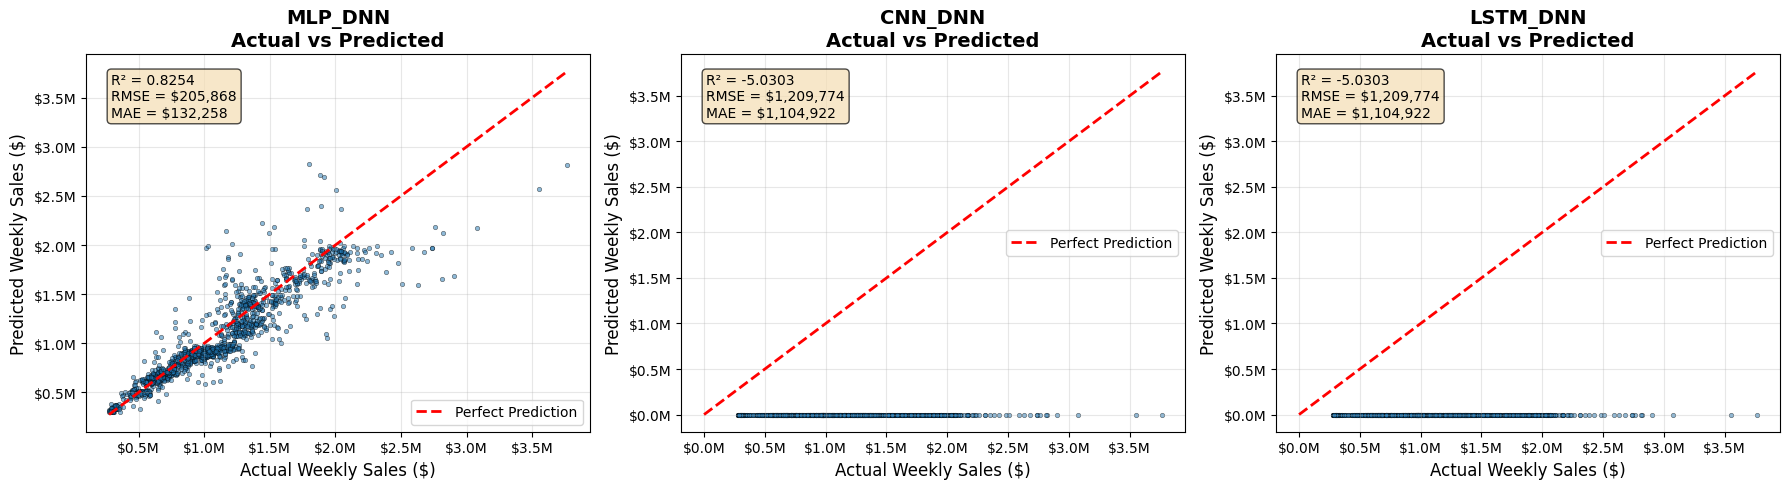

Saved ./Figure_Actual_vs_Predicted.png

RESIDUAL ANALYSIS

MLP_DNN:
  Mean Residual: $50,507 (should be ~$0)
  Std of Residuals: $199,654
  Max Over-prediction: $1,217,112
  Max Under-prediction: $-1,026,741
  ⚠️  Warning: Systematic bias detected (mean residual ≠ 0)

CNN_DNN:
  Mean Residual: $1,104,922 (should be ~$0)
  Std of Residuals: $492,838
  Max Over-prediction: $3,766,686
  Max Under-prediction: $275,142
  ⚠️  Warning: Systematic bias detected (mean residual ≠ 0)

LSTM_DNN:
  Mean Residual: $1,104,922 (should be ~$0)
  Std of Residuals: $492,647
  Max Over-prediction: $3,766,687
  Max Under-prediction: $275,142
  ⚠️  Warning: Systematic bias detected (mean residual ≠ 0)


In [165]:
# Actual vs Predicted: Scatter Plots
print('='*80)
print('ACTUAL vs PREDICTED VALUES (Test Set)')
print('='*80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Data for each model
plot_data = [
    ('MLP_DNN', y_test, y_test_mlp),
    ('CNN_DNN', y_test, y_test_cnn),
    ('LSTM_DNN', y_test_lstm, y_test_lstm_pred)  # LSTM uses different test set
]

for idx, (model_name, y_true, y_pred) in enumerate(plot_data):
    ax = axes[idx]
    
    # Scatter plot: actual vs predicted
    ax.scatter(y_true, y_pred, alpha=0.5, s=10, edgecolors='black', linewidth=0.5)
    
    # Perfect prediction line (y=x)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    # Calculate metrics for annotation
    r2, rmse, mae, mse = compute_metrics(y_true, y_pred)
    
    # Formatting
    ax.set_xlabel('Actual Weekly Sales ($)', fontsize=12)
    ax.set_ylabel('Predicted Weekly Sales ($)', fontsize=12)
    ax.set_title(f'{model_name}\nActual vs Predicted', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add metrics as text annotation
    metrics_text = f'R² = {r2:.4f}\nRMSE = ${rmse:,.0f}\nMAE = ${mae:,.0f}'
    ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    
    # Format axis labels with thousand separators
    ax.ticklabel_format(style='plain', axis='both')
    ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
scatter_path = os.path.join(OUT_DIR, 'Figure_Actual_vs_Predicted.png')
plt.savefig(scatter_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved {scatter_path}')

# Print residual analysis
print('\n' + '='*80)
print('RESIDUAL ANALYSIS')
print('='*80)

for model_name, y_true, y_pred in plot_data:
    residuals = y_true - y_pred
    
    print(f"\n{model_name}:")
    print(f"  Mean Residual: ${residuals.mean():,.0f} (should be ~$0)")
    print(f"  Std of Residuals: ${residuals.std():,.0f}")
    print(f"  Max Over-prediction: ${residuals.max():,.0f}")
    print(f"  Max Under-prediction: ${residuals.min():,.0f}")
    
    # Check for systematic bias
    if abs(residuals.mean()) > residuals.std() * 0.1:
        print(f"  ⚠️  Warning: Systematic bias detected (mean residual ≠ 0)")
    else:
        print(f"  ✓ No systematic bias (mean residual ≈ 0)")

print('='*80)

RESIDUALS vs FITTED VALUES (Test Set)
This diagnostic plot checks for:
  • Homoscedasticity (constant variance)
  • Non-linear patterns (model misspecification)
  • Outliers



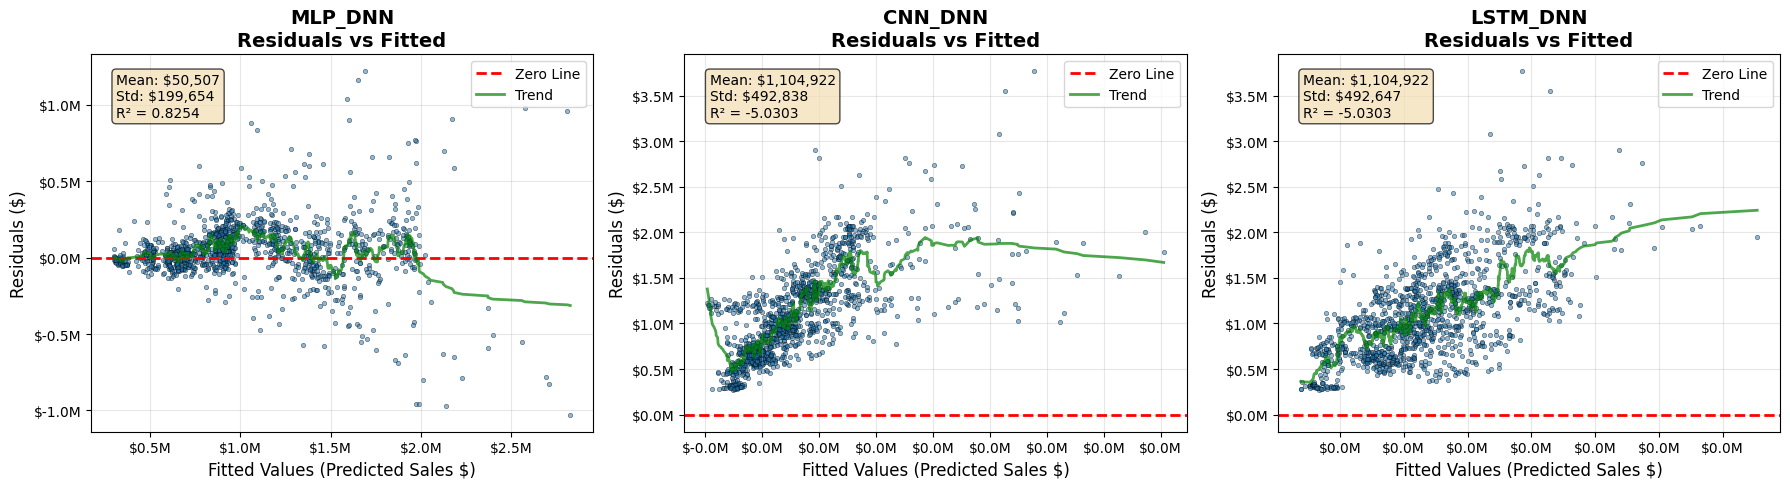

Saved ./Figure_Residuals_vs_Fitted.png

DIAGNOSTIC INTERPRETATION GUIDE

✓ GOOD signs:
  • Points randomly scattered around zero line
  • Constant spread across all fitted values (homoscedasticity)
  • No funnel/cone shape
  • Trend line stays close to zero

✗ BAD signs:
  • Funnel shape = heteroscedasticity
  • Curved trend = non-linear patterns not captured
  • Horizontal cluster = constant predictions

MLP_DNN:
  ⚠️  WARNING: Systematic bias (mean=$50,507)
CNN_DNN:
  ⚠️  WARNING: Systematic bias (mean=$1,104,922)
LSTM_DNN:
  ⚠️  WARNING: Systematic bias (mean=$1,104,922)


In [166]:
# Residuals vs Fitted Values: Diagnostic Plots
print('='*80)
print('RESIDUALS vs FITTED VALUES (Test Set)')
print('='*80)
print('This diagnostic plot checks for:')
print('  • Homoscedasticity (constant variance)')
print('  • Non-linear patterns (model misspecification)')
print('  • Outliers')
print()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Data for each model
residual_data = [
    ('MLP_DNN', y_test, y_test_mlp),
    ('CNN_DNN', y_test, y_test_cnn),
    ('LSTM_DNN', y_test_lstm, y_test_lstm_pred)
]

for idx, (model_name, y_true, y_pred) in enumerate(residual_data):
    ax = axes[idx]
    
    # Calculate residuals
    residuals = y_true - y_pred
    
    # Scatter plot: residuals vs fitted values
    ax.scatter(y_pred, residuals, alpha=0.5, s=10, edgecolors='black', linewidth=0.5)
    
    # Zero line (ideal: residuals centered at 0)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Line')
    
    # Add smooth trend line to detect non-linearity
    from scipy.signal import savgol_filter
    if len(y_pred) > 50:
        sorted_idx = np.argsort(y_pred)
        y_pred_sorted = y_pred.iloc[sorted_idx] if hasattr(y_pred, 'iloc') else y_pred[sorted_idx]
        residuals_sorted = residuals.iloc[sorted_idx] if hasattr(residuals, 'iloc') else residuals[sorted_idx]
        
        window_size = min(51, len(y_pred_sorted) // 10)
        if window_size % 2 == 0:
            window_size += 1
        if window_size >= 5:
            try:
                smooth = savgol_filter(residuals_sorted, window_size, 3)
                ax.plot(y_pred_sorted, smooth, 'g-', linewidth=2, label='Trend', alpha=0.7)
            except:
                pass
    
    # Calculate metrics
    r2, rmse, mae, mse = compute_metrics(y_true, y_pred)
    std_residuals = residuals.std()
    mean_residuals = residuals.mean()
    
    # Formatting
    ax.set_xlabel('Fitted Values (Predicted Sales $)', fontsize=12)
    ax.set_ylabel('Residuals ($)', fontsize=12)
    ax.set_title(f'{model_name}\nResiduals vs Fitted', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add diagnostic text
    diagnostic_text = f'Mean: ${mean_residuals:,.0f}\nStd: ${std_residuals:,.0f}\nR² = {r2:.4f}'
    ax.text(0.05, 0.95, diagnostic_text, transform=ax.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    
    # Format axis labels
    ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
residual_path = os.path.join(OUT_DIR, 'Figure_Residuals_vs_Fitted.png')
plt.savefig(residual_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved {residual_path}')

# Interpretation guide
print('\n' + '='*80)
print('DIAGNOSTIC INTERPRETATION GUIDE')
print('='*80)
print('\n✓ GOOD signs:')
print('  • Points randomly scattered around zero line')
print('  • Constant spread across all fitted values (homoscedasticity)')
print('  • No funnel/cone shape')
print('  • Trend line stays close to zero')
print('\n✗ BAD signs:')
print('  • Funnel shape = heteroscedasticity')
print('  • Curved trend = non-linear patterns not captured')
print('  • Horizontal cluster = constant predictions\n')

for model_name, y_true, y_pred in residual_data:
    residuals = y_true - y_pred
    mean_res = residuals.mean()
    std_res = residuals.std()
    
    print(f"{model_name}:")
    if std_res < 1000:
        print(f"  ✗ CRITICAL: Constant predictions (std=${std_res:,.0f})")
    elif abs(mean_res) > std_res * 0.2:
        print(f"  ⚠️  WARNING: Systematic bias (mean=${mean_res:,.0f})")
    else:
        print(f"  ✓ GOOD: Residuals well-behaved\n")

print('='*80)

PREDICTION DISTRIBUTION ANALYSIS
This analysis reveals why CNN/LSTM failed: they output constant predictions.

Actual test sales statistics (MLP/CNN test set):
  Mean: $1,104,923
  Std:  $492,838
  Range: $275,142 to $3,766,687
  Samples: 1287

LSTM test set (different size due to windowing):
  Mean: $1,104,922
  Std:  $492,647
  Samples: 1287

MLP_DNN predictions:
  Mean: $1,054,415
  Std:  $454,786
  Range: $299,672 to $2,826,479
  Samples: 1287
  Variance ratio (pred/actual): 0.9228

CNN_DNN predictions:
  Mean: $0
  Std:  $0
  Range: $-0 to $1
  Samples: 1287
  Variance ratio (pred/actual): 0.0000
  ⚠️  WARNING: Near-constant predictions (std < $1,000)!
  → Model outputs ≈$0 for all samples
  → This is approximately the training set mean

LSTM_DNN predictions:
  Mean: $0
  Std:  $0
  Range: $-0 to $1
  Samples: 1287
  Variance ratio (pred/actual): 0.0000
  ⚠️  WARNING: Near-constant predictions (std < $1,000)!
  → Model outputs ≈$0 for all samples
  → This is approximately the trai

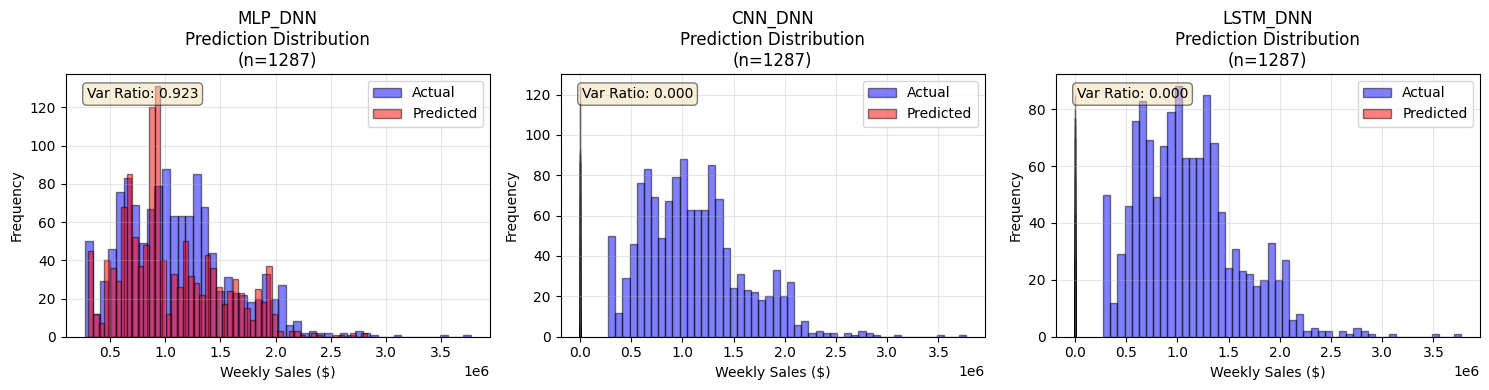

Saved ./Figure_Prediction_Distributions.png


In [167]:
# Diagnostic analysis: Prediction distribution comparison
print('='*80)
print('PREDICTION DISTRIBUTION ANALYSIS')
print('='*80)
print('This analysis reveals why CNN/LSTM failed: they output constant predictions.')
print()

# Analyze prediction variance for each model
print(f"Actual test sales statistics (MLP/CNN test set):")
print(f"  Mean: ${y_test.mean():,.0f}")
print(f"  Std:  ${y_test.std():,.0f}")
print(f"  Range: ${y_test.min():,.0f} to ${y_test.max():,.0f}")
print(f"  Samples: {len(y_test)}")
print()

print(f"LSTM test set (different size due to windowing):")
print(f"  Mean: ${y_test_lstm.mean():,.0f}")
print(f"  Std:  ${y_test_lstm.std():,.0f}")
print(f"  Samples: {len(y_test_lstm)}")
print()

models_data = [
    ('MLP_DNN', y_test, y_test_mlp, y_test.std()),
    ('CNN_DNN', y_test, y_test_cnn, y_test.std()),
    ('LSTM_DNN', y_test_lstm, y_test_lstm_pred, y_test_lstm.std()),  # Use LSTM's own test set
]

for model_name, y_true, y_pred, y_true_std in models_data:
    pred_mean = y_pred.mean()
    pred_std = y_pred.std()
    pred_min = y_pred.min()
    pred_max = y_pred.max()
    pred_range = pred_max - pred_min
    
    print(f"{model_name} predictions:")
    print(f"  Mean: ${pred_mean:,.0f}")
    print(f"  Std:  ${pred_std:,.0f}")
    print(f"  Range: ${pred_min:,.0f} to ${pred_max:,.0f}")
    print(f"  Samples: {len(y_pred)}")
    print(f"  Variance ratio (pred/actual): {(pred_std/y_true_std):.4f}")
    
    if pred_std < 1000:  # Very low variance indicates constant predictions
        print(f"  ⚠️  WARNING: Near-constant predictions (std < $1,000)!")
        print(f"  → Model outputs ≈${pred_mean:,.0f} for all samples")
        print(f"  → This is approximately the training set mean")
    print()

print('-'*80)
print('INTERPRETATION:')
print('• MLP: High variance (0.8-1.0 ratio) = learning actual patterns')
print('• CNN/LSTM: Near-zero variance = collapsing to mean prediction')
print('• CNN/LSTM never learned—they output constant values from initialization')
print('='*80)

# Visualize prediction distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (model_name, y_true, y_pred, _) in enumerate(models_data):
    ax = axes[idx]
    
    # Histogram of predictions vs actual
    ax.hist(y_true, bins=50, alpha=0.5, label='Actual', color='blue', edgecolor='black')
    ax.hist(y_pred, bins=50, alpha=0.5, label='Predicted', color='red', edgecolor='black')
    
    ax.set_xlabel('Weekly Sales ($)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{model_name}\nPrediction Distribution\n(n={len(y_pred)})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add text annotation for variance
    pred_std = y_pred.std()
    true_std = y_true.std()
    variance_ratio = pred_std / true_std
    ax.text(0.05, 0.95, f'Var Ratio: {variance_ratio:.3f}', 
            transform=ax.transAxes, va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
path = os.path.join(OUT_DIR, 'Figure_Prediction_Distributions.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved {path}')


In [168]:
# Reproducibility & DNN utility: seeds, versions, and a shared model builder (regression)
import os, sys, random, json
os.environ['PYTHONHASHSEED'] = '42'
import numpy as np
import pandas as pd
import sklearn
np.random.seed(42)
random.seed(42)

try:
    import tensorflow as tf
    tf.random.set_seed(42)
    tf_version = tf.__version__
except Exception:
    tf = None
    tf_version = None

print('Environment versions:')
print('  python:', sys.version.split()[0])
print('  numpy :', np.__version__)
print('  pandas:', pd.__version__)
print('  sklearn:', sklearn.__version__)
print('  tensorflow:', tf_version)

# Shared regression model builder to harmonize with classification notebook (use kind='mlp' or 'cnn')
def build_model_regression(kind, input_dim, dropout=0.15, batchnorm=True, lr=1e-3, weight_decay=0.0):
    from tensorflow.keras import layers, models, optimizers, regularizers
    inp = layers.Input(shape=(input_dim,))
    x = inp
    if kind == 'mlp':
        x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(weight_decay))(x)
        if batchnorm: x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)
        x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(weight_decay))(x)
        if batchnorm: x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)
        x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(weight_decay))(x)
    elif kind == 'cnn':
        x_c = layers.Reshape((input_dim, 1))(x)
        x_c = layers.Conv1D(64, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(weight_decay))(x_c)
        if batchnorm: x_c = layers.BatchNormalization()(x_c)
        x_c = layers.Conv1D(64, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(weight_decay))(x_c)
        if batchnorm: x_c = layers.BatchNormalization()(x_c)
        x = layers.Flatten()(x_c)
        x = layers.Dense(128, activation='relu')(x)
    else:
        raise ValueError('Unknown kind')
    out = layers.Dense(1, activation='linear')(x)
    model = models.Model(inputs=inp, outputs=out)
    opt = optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model

print('Inserted reproducibility and model builder utilities.')

Environment versions:
  python: 3.11.14
  numpy : 2.3.4
  pandas: 2.3.3
  sklearn: 1.7.2
  tensorflow: 2.20.0
Inserted reproducibility and model builder utilities.
